 # **MOVIE RECCOMENDATION SYSTEM**

## 1.0 **Business Undertanding**: 

The project aims at analyzing movie lens data to understand viewer preferences across various movies and varying genres. The aim is to understand factors than influence consumer dynamics. This will inform content recommendations to users in our video streaming platform. The user dynamics, will also influence strategic investment decision 

### 1.1 **Business objective**

Our aim is to build a movie recommendation system for a company offering  subscription based streaming services.  
The goal is to improve user experience as part of the customer retention strategy by:  
Offering personalized user experience.   
promoting product consumption  by users to increase revenue.  
Reduce user fatigue when scrolling over the entire movie database.  
We will seek to create a recommendation system to suggest five movies for a new user using content based filetering by factoring in the desired genre.  
We shall also create a recommendation system  to suggest top new 5 movies for a user based on their  rating history

# 2.0 **Data Understanding**:

Our analysis is based on the Movie Lens dataset from the GroupLens research lab at the University of Minnesota.The data contains 100,000 ratings and 3,600 tag applications applied to 9,000 movies by 600 users.  
The data set comprises of movie ratings by individual users, movie titles, their associated genres. It is suitable for addressing problems in the entertainment industry such as content based recommendations to subscribers, designing marketing strategies to promote  content uptake as well as influencing investments in content based movie production informed by customer behaviour.
The data is contained in various separate files namely:  
**Movies.csv:**  
This shows the identifier (id) of the movie.  
The name of the movie including production year.      
The various  genres that the movie belongs to.    

**ratings.csv**   
This data shows the customer rating per movie. The data is organized in 4 columns namey:  
userId-The unique customer identifier.  
MovieID-The uniqque movie identifier.  
rating-Customer satisfaction score on a scale of 0 to 5.  
timestamp-Time when the cusotmer rated the movie.  
**tags.csv**  
This shows the  tag/label applied on each movie by  each viewer.  
It has the below fields:  
userId-The unique viewer identifier.  
movieId-the unique movie identifiers.  
tag-The label applied by the viewer on the movie.  
timestamp-when the label was applied by the user.  
**links.csv**  
It hosts the identifiers that can be used to trace the same movie from other content providers specifically imdbId	and tmdbId.  

**We consinder the data set suitable for our project since:**   
It has large content allowing for gneralization.  
It has rich features such as genres and release year for content based reocommedations.  
It has features such as user ratings allowing for collaborative approach.

### **Success Criteria**

Our best model will be be based on RMSE, we shall adopt the model with the least RMSE

# 3.0 **Data Preparation**:

To support in the analysis and modelling we used the following python packages:  
**Pandas**:To lead,clean and structure data into data frames.  
**Numpy:** To undertaken numerical operations.  
**Matplotlib:** To visulaize the data.   
**Seaborn** to visualize the data



In [2]:
#importing the necessary libralies:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import numpy as np

In [3]:
#Loading and previewing links data set:
links=pd.read_csv('links.csv')
links.head()

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [4]:
links.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   movieId  9742 non-null   int64  
 1   imdbId   9742 non-null   int64  
 2   tmdbId   9734 non-null   float64
dtypes: float64(1), int64(2)
memory usage: 228.5 KB


links dataset has 9742 movies and has no null values

In [5]:
#loading and previewing movies data set:
movies=pd.read_csv('movies.csv')
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [6]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB


Movies data set has 9742 fields and has no null values.

In [7]:
#loading and previewing ratings data set:
ratings=pd.read_csv('ratings.csv')
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [8]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


Rating dataset has 100836 values and has no null values. It infers that  various movies have been rated mutiple times.

In [9]:
#loading and previewing tags data set:
tags=pd.read_csv('tags.csv')
tags.head()

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


In [10]:
tags.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3683 entries, 0 to 3682
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   userId     3683 non-null   int64 
 1   movieId    3683 non-null   int64 
 2   tag        3683 non-null   object
 3   timestamp  3683 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 115.2+ KB


Tags data has only 3683 entries. This implies that most movies might not have bene tagged.

Since our modelling is not location based we chose to use only the movies ,ratings and tags data

## 3.11 **Exploratory data analysis**:

We will merge the movies and ratings data using the movieID

In [11]:
movie_ratings=pd.merge(ratings,movies,on='movieId')
movie_ratings.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [12]:
movie_ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
 4   title      100836 non-null  object 
 5   genres     100836 non-null  object 
dtypes: float64(1), int64(3), object(2)
memory usage: 4.6+ MB


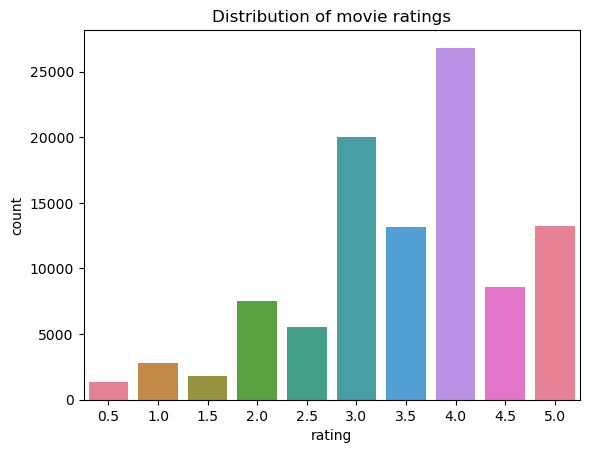

In [13]:
#summary distribution of movie ratings:---typed
sns.countplot(x='rating',data=ratings,hue='rating',palette='husl',legend=False)
plt.title('Distribution of movie ratings')
plt.show()

Most of the movies were assigned a rating of between 3 and 5. 
A rating of 4 was the most poular among the movies.

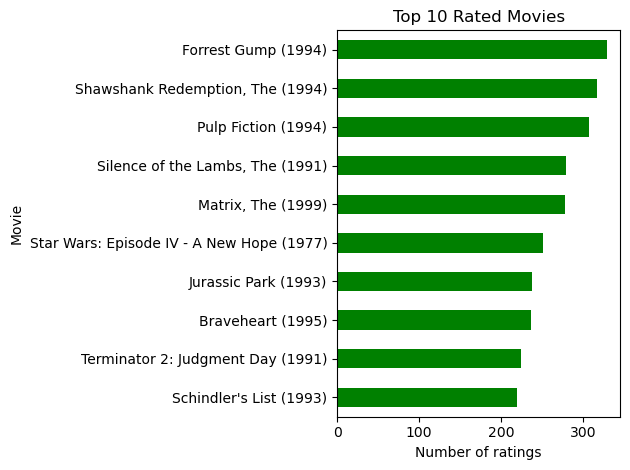

In [14]:
#Top 10 rated movies:
top_10_rated=movie_ratings.groupby('title').size().sort_values(ascending=False).head(10)
top_10_rated.plot(kind='barh',title='Top 10 Rated Movies',color='green')
plt.gca().invert_yaxis()
plt.xlabel('Number of ratings')
plt.ylabel('Movie')
plt.tight_layout()
plt.show()

In [15]:
#Summary of movie rating:
movie_summary=ratings.groupby('movieId').agg(rating_count=('rating','count'),rating_mean=('rating','mean')).reset_index()
movie_summary.head()

,movieId,rating_count,rating_mean
0,1,215,3.920930
1,2,110,3.431818
2,3,52,3.259615
3,4,7,2.357143
4,5,49,3.071429


In [16]:
# Merging rating summary with movies data:
movie_summary_merged=pd.merge(movies,movie_summary,on='movieId')
movie_summary_merged.head()

,movieId,title,genres,rating_count,rating_mean
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,215,3.920930
1,2,Jumanji (1995),Adventure|Children|Fantasy,110,3.431818
2,3,Grumpier Old Men (1995),Comedy|Romance,52,3.259615
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,7,2.357143
4,5,Father of the Bride Part II (1995),Comedy,49,3.071429


In [17]:
#to view datils of movie_summary_merged

movie_summary_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9724 entries, 0 to 9723
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   movieId       9724 non-null   int64  
 1   title         9724 non-null   object 
 2   genres        9724 non-null   object 
 3   rating_count  9724 non-null   int64  
 4   rating_mean   9724 non-null   float64
dtypes: float64(1), int64(2), object(2)
memory usage: 380.0+ KB


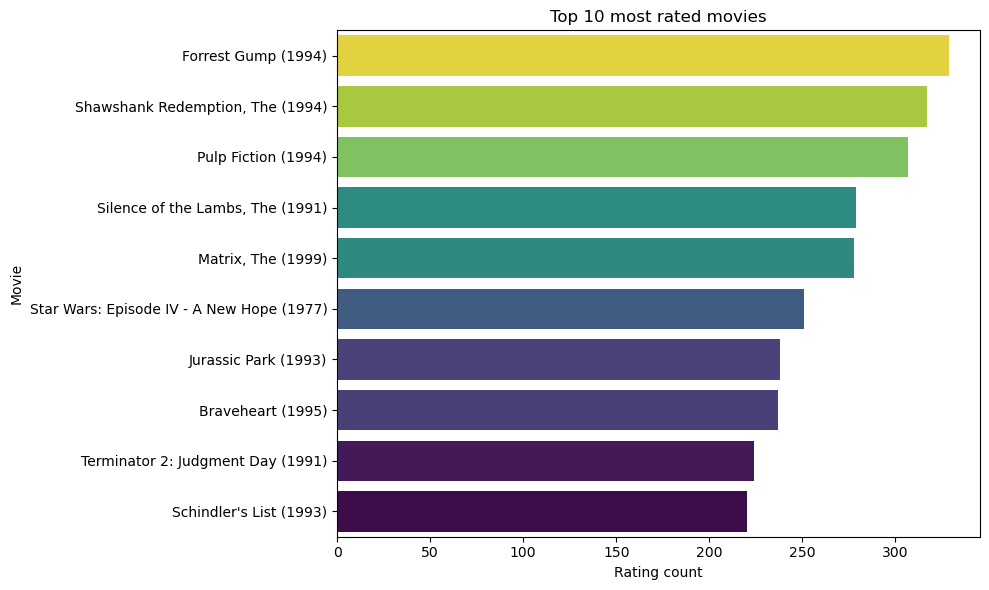

In [18]:
# viswing top 10 movies by rating count:
top_10_movies_count=movie_summary_merged.sort_values(by='rating_count',ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x='rating_count',y='title',data=top_10_movies_count,palette='viridis',hue='rating_count',legend=False)
plt.title('Top 10 most rated movies')
plt.xlabel('Rating count')
plt.ylabel('Movie')
plt.tight_layout()
plt.show()

Top 10 most rated  movies attracted  over 200 ratings.

In [19]:
#converting genres to a list:
movie_summary_merged['genre']=movie_summary_merged['genres'].str.split('|')
#exploding the genres:
movie_summary_merged=movie_summary_merged.explode('genre')
#summary of raings per genre:
genre_counts=movie_summary_merged['genre'].value_counts()
movie_summary_merged.head(2)

,movieId,title,genres,rating_count,rating_mean,genre
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,215,3.92093,Adventure
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,215,3.92093,Animation


C:\Users\HP\AppData\Local\Temp\ipykernel_19432\1406303507.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.index,y=genre_counts.values,palette='viridis')


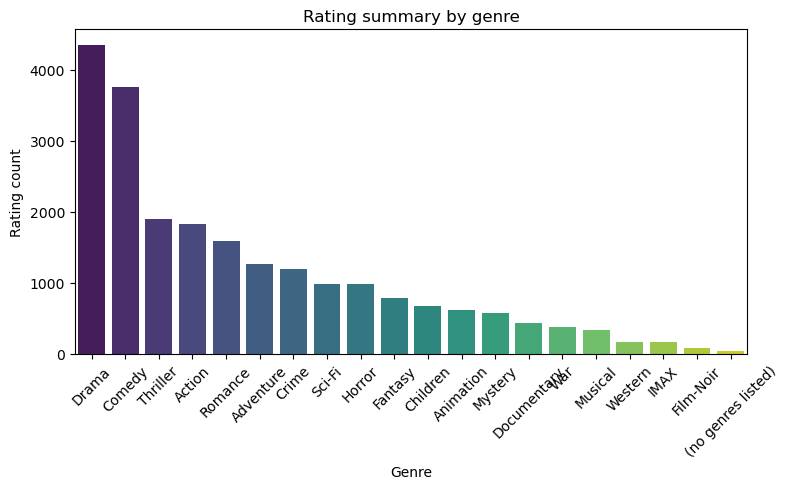

In [20]:
# Visualizing ratings per exploded genre:
plt.figure(figsize=(8,5))
sns.barplot(x=genre_counts.index,y=genre_counts.values,palette='viridis')
plt.xlabel('Genre')
plt.ylabel('Rating count')
plt.xticks(rotation=45)
plt.title('Rating summary by genre')
plt.tight_layout()
plt.show()

Movies centred around Drama ,Comedy and Action attract more reviews. This is an indication that they are the most viewed.

#converting the genres string to a list:
movie_summary_merged['genres']=movie_summary_merged['genres'].str.split('|')
movie_summary_merged.head()

In [21]:
#extracting year of production from title:
movie_summary_merged['year']=movie_summary_merged['title'].str.extract(r'\((\d{4})\)')

In [22]:
#converting year to number format:
movie_summary_merged['year']=pd.to_numeric(movie_summary_merged['year'],errors='coerce')
movie_summary_merged.head()

,movieId,title,genres,rating_count,rating_mean,genre,year
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,215,3.92093,Adventure,1995.0
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,215,3.92093,Animation,1995.0
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,215,3.92093,Children,1995.0
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,215,3.92093,Comedy,1995.0
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,215,3.92093,Fantasy,1995.0


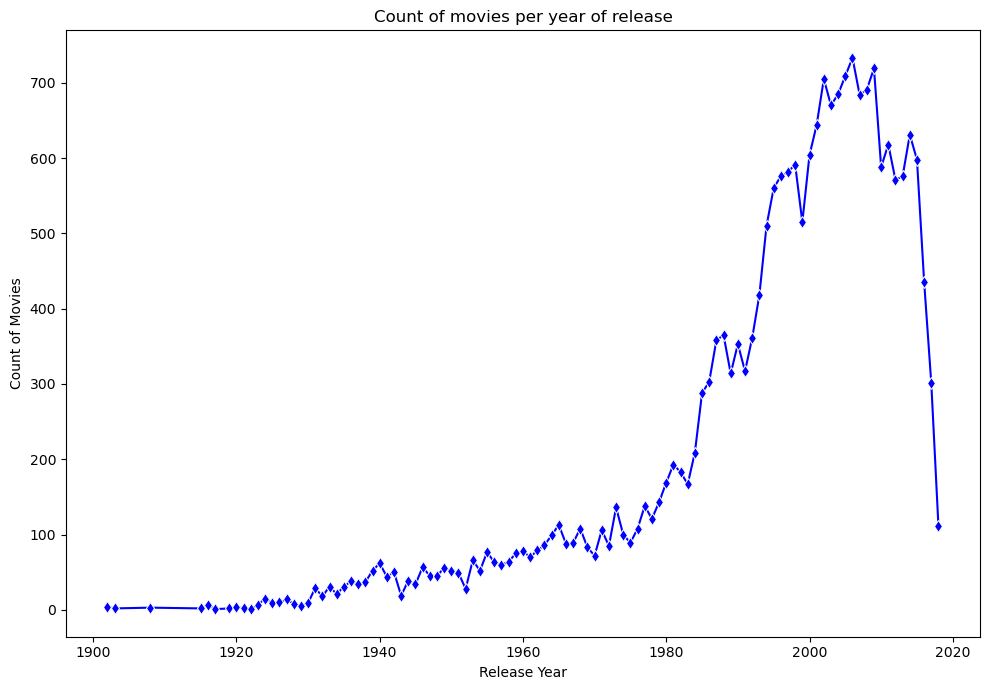

In [23]:
#distribution of movies per year of release:-typed
#dropping movies with no year:
movie_summary_merged=movie_summary_merged.dropna(subset=['year'])
#summarizing by year:
Movies_per_year=movie_summary_merged.groupby('year').size()
#plotting movoes per year of  release:
plt.figure(figsize=(10,7))
sns.lineplot(x=Movies_per_year.index,y=Movies_per_year.values,color='blue',marker='d')
plt.title('Count of movies per year of release')
plt.xlabel('Release Year')
plt.ylabel('Count of Movies')
plt.tight_layout()
plt.show()

Most of the rated movies were released between 1990 and 2018.  
There has been a sustained drop in rated movies released after 2002.

In [24]:
movie_summary_merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22030 entries, 0 to 9723
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   movieId       22030 non-null  int64  
 1   title         22030 non-null  object 
 2   genres        22030 non-null  object 
 3   rating_count  22030 non-null  int64  
 4   rating_mean   22030 non-null  float64
 5   genre         22030 non-null  object 
 6   year          22030 non-null  float64
dtypes: float64(2), int64(2), object(3)
memory usage: 1.3+ MB


In [26]:
final_df=movie_summary_merged